In [1]:
%load_ext autoreload
%autoreload 2
%aimport -torch

In [2]:
import os
import sys

TOKENIZER_PATH = '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/1d-tokenizer'
TOKENIZER = 'TaTitok'

sys.path.append(TOKENIZER_PATH)

In [52]:
model_name = 'titok_sl256_vq8k'
RECONSTRUCTION_PATH = f'/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/{model_name}'
os.makedirs(RECONSTRUCTION_PATH, exist_ok=True)

In [53]:
import torch
from PIL import Image
import numpy as np
from huggingface_hub import hf_hub_download
from modeling.titok import TiTok
import torchvision.transforms as T
from utils import load_all_images
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
# load the pretrained models from huggingface
tokenizer = TiTok.from_pretrained("yucornetto/tokenizer_titok_sl256_vq8k_imagenet")

tokenizer.eval()
tokenizer.requires_grad_(False)

device = "cuda"
tokenizer = tokenizer.to(device)

In [27]:
img_path = "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/original/line_chart.png"
image = torch.from_numpy(np.array(Image.open(img_path)).astype(np.float32)).permute(2, 0, 1).unsqueeze(0) / 255.0

In [28]:
# Check what you're working with
img = Image.open(img_path)
print(f"Original size: {img.size}")
print(f"Aspect ratio: {max(img.size) / min(img.size):.2f}")

Original size: (712, 626)
Aspect ratio: 1.14


In [42]:
def preprocess_image_for_titok(image_path, size=256, device='cuda', disable_resize=False):
    """Load and preprocess a single image for TiTok tokenizer"""
    # Load image
    image = Image.open(image_path).convert("RGB")
    
    if disable_resize:
        # Only center crop without resizing - keeps original pixel resolution
        cropper = T.CenterCrop((size, size))
        image = cropper(image)
    else:
        # TiTok-specific preprocessing with resize
        # First resize then center crop to ensure exact size
        rescaler = T.Resize(size, interpolation=T.InterpolationMode.LANCZOS)  # High quality
        cropper = T.CenterCrop((size, size))
        preprocessor = T.Compose([rescaler, cropper])
        image = preprocessor(image)
    
    # Convert to tensor and normalize to [0, 1] (TiTok expects this range)
    image = np.array(image).astype(np.float32)
    tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0) / 255.0
    
    return tensor.to(device)

def tensor_to_pil_titok(tensor):
    """Convert TiTok tensor back to PIL image"""
    # Tensor is in range [0, 1], convert to [0, 255]
    tensor = torch.clamp(tensor, 0.0, 1.0)
    tensor = (tensor * 255.0)

    # Convert BCHW to HWC and to numpy
    if tensor.dim() == 4:  # Remove batch dimension if present
        tensor = tensor.squeeze(0)
    image_array = tensor.permute(1, 2, 0).cpu().numpy().astype(np.uint8)
    
    return Image.fromarray(image_array)

In [50]:
# Simple loop for FlowMo processing
folder_path = '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/original'
_, _, image_paths = load_all_images(folder_path)

Loaded: graph_theory1.png
Loaded: line_chart.png
Loaded: logo1.png
Loaded: logo2.png
Loaded: math_draft1.png
Loaded: menu.jpeg
Loaded: physics1.png
Loaded: physics2.png



Processing image 1: graph_theory1.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
VQ mode - encoded tokens shape: torch.Size([1, 1, 256])
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: graph_theory1_256.png


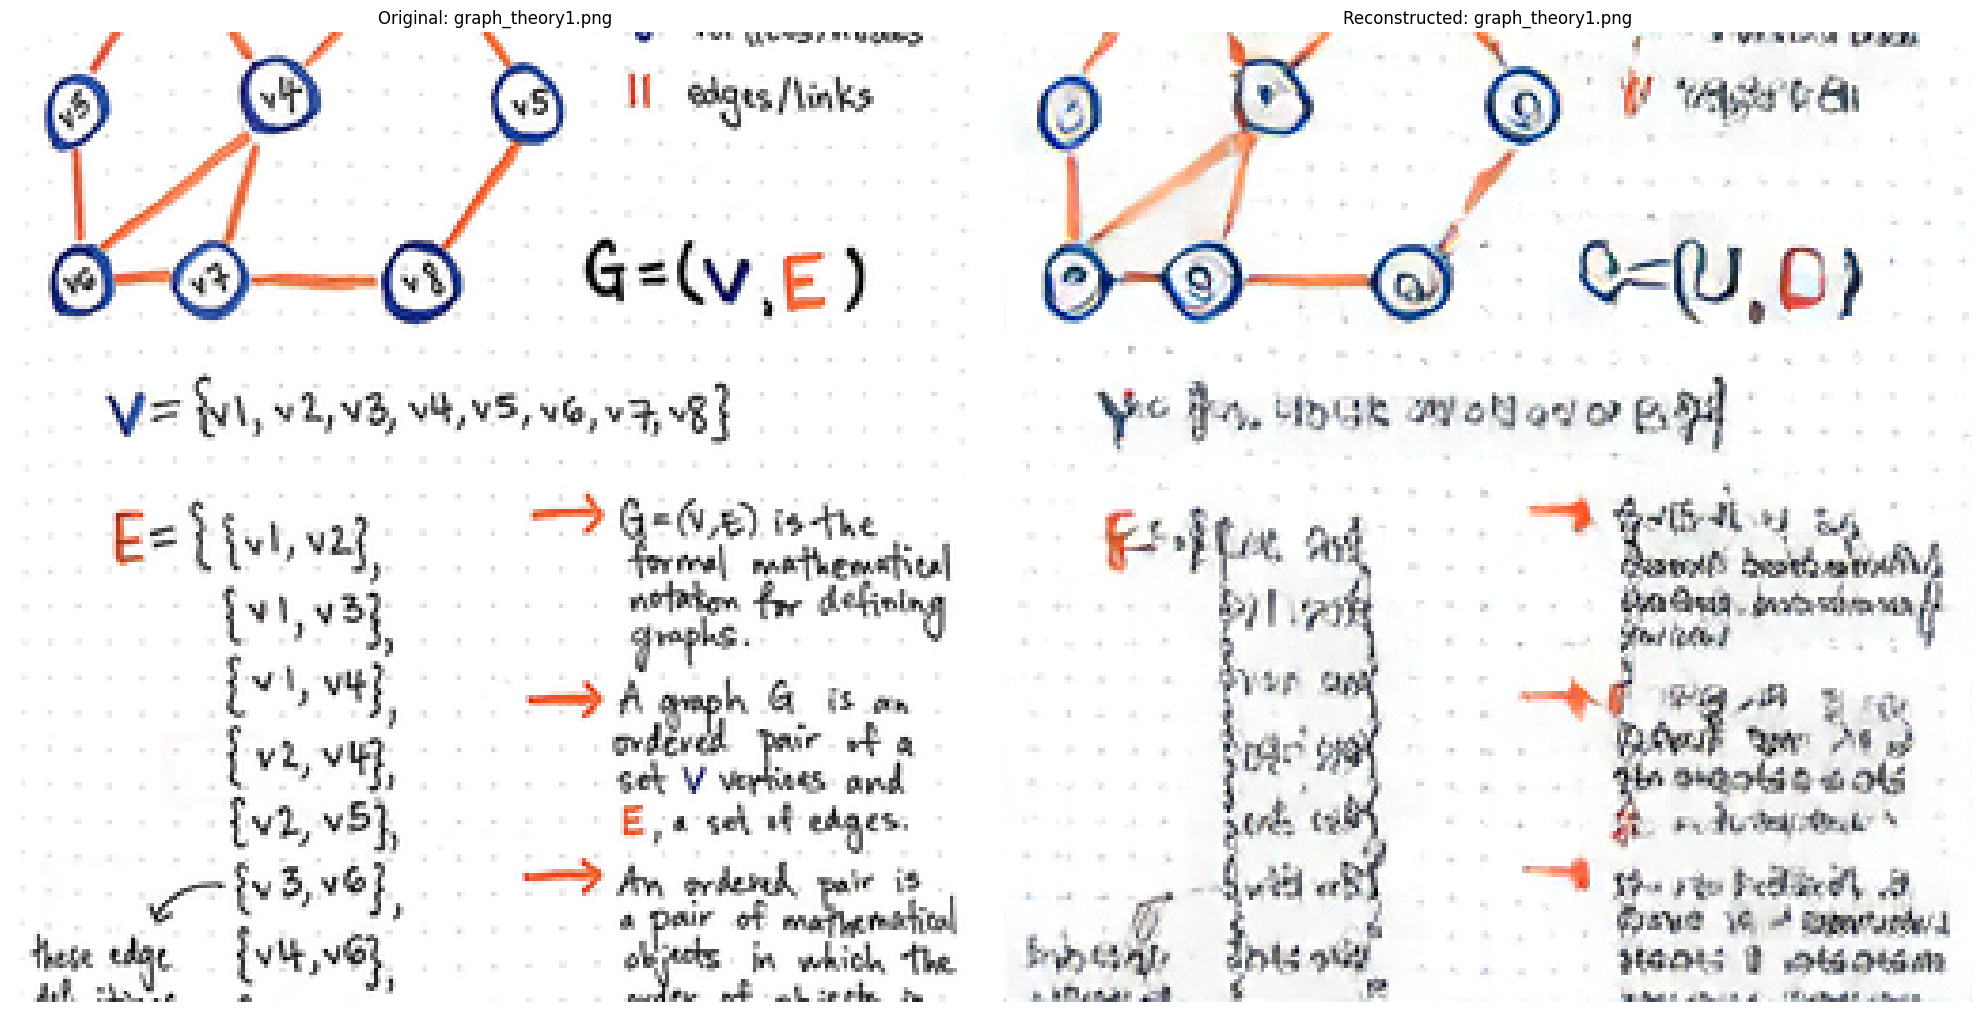


Processing image 2: line_chart.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
VQ mode - encoded tokens shape: torch.Size([1, 1, 256])
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: line_chart_256.png


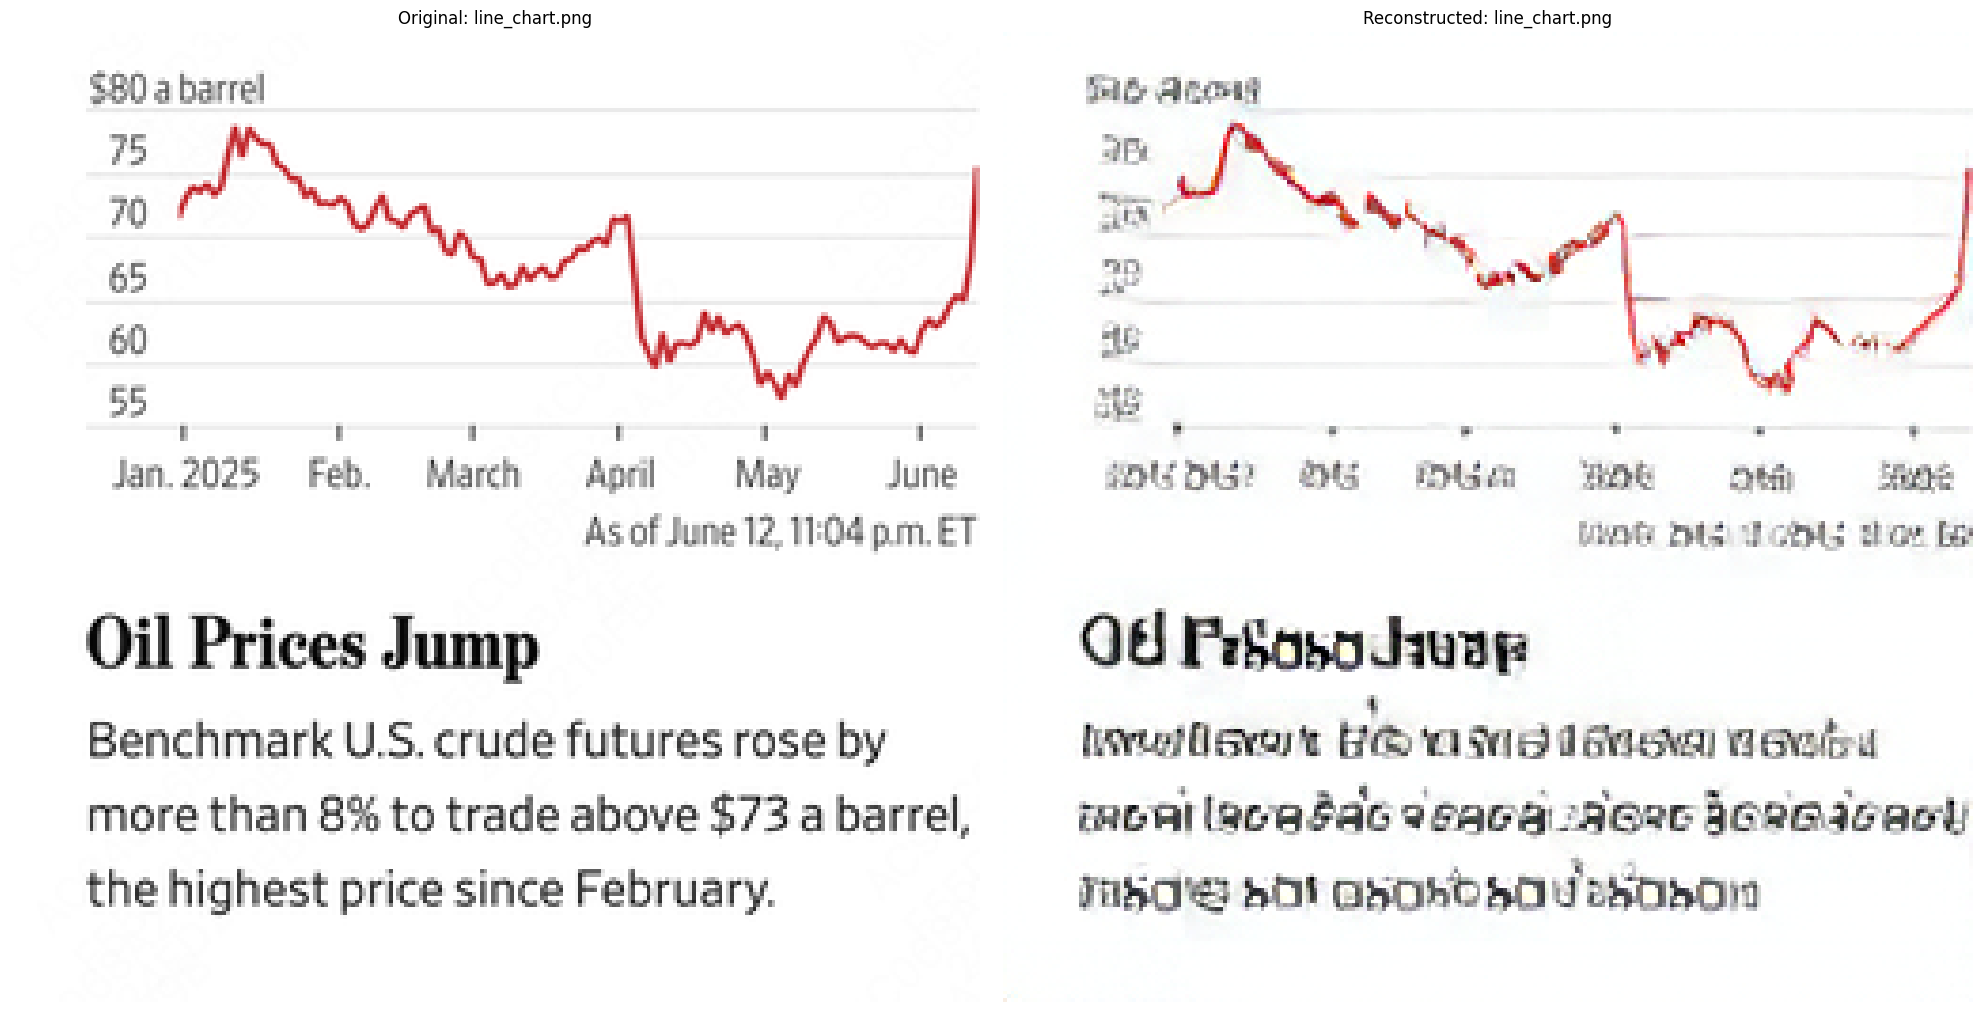


Processing image 3: logo1.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
VQ mode - encoded tokens shape: torch.Size([1, 1, 256])
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: logo1_256.png


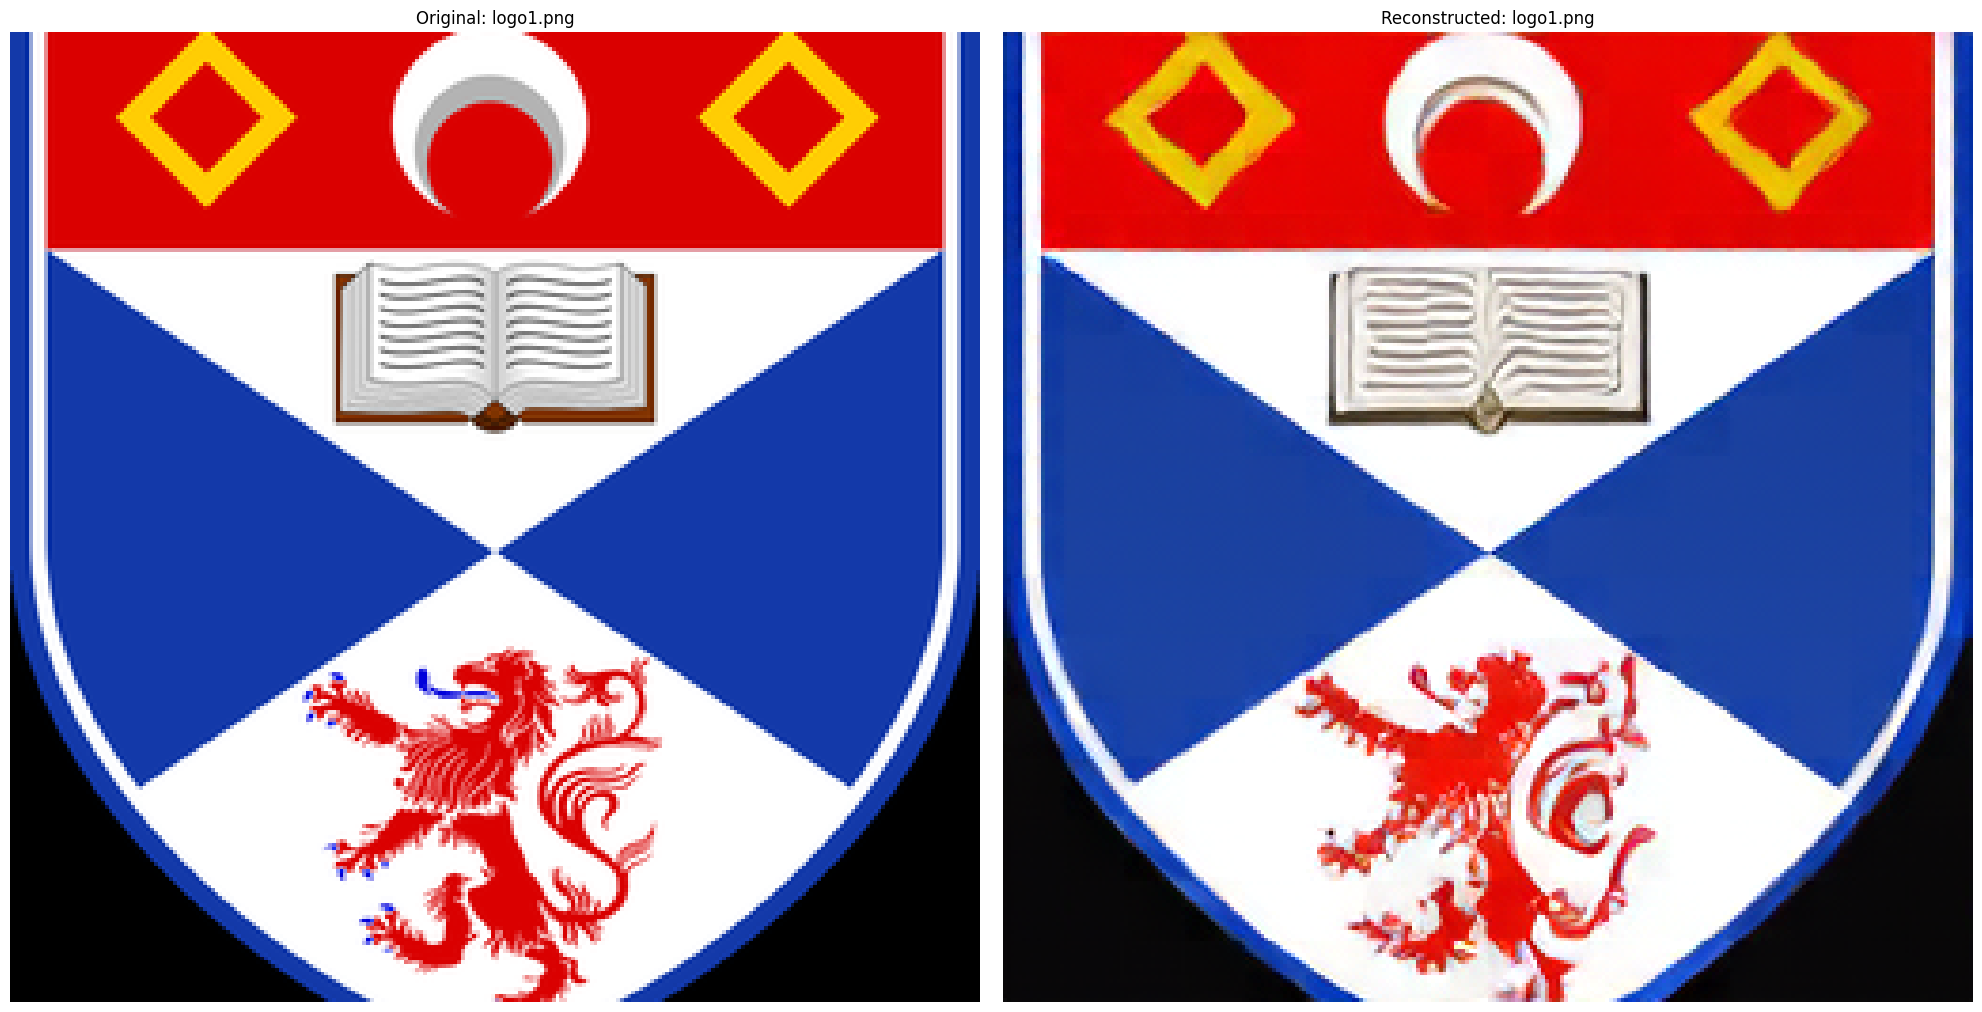


Processing image 4: logo2.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
VQ mode - encoded tokens shape: torch.Size([1, 1, 256])
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: logo2_256.png


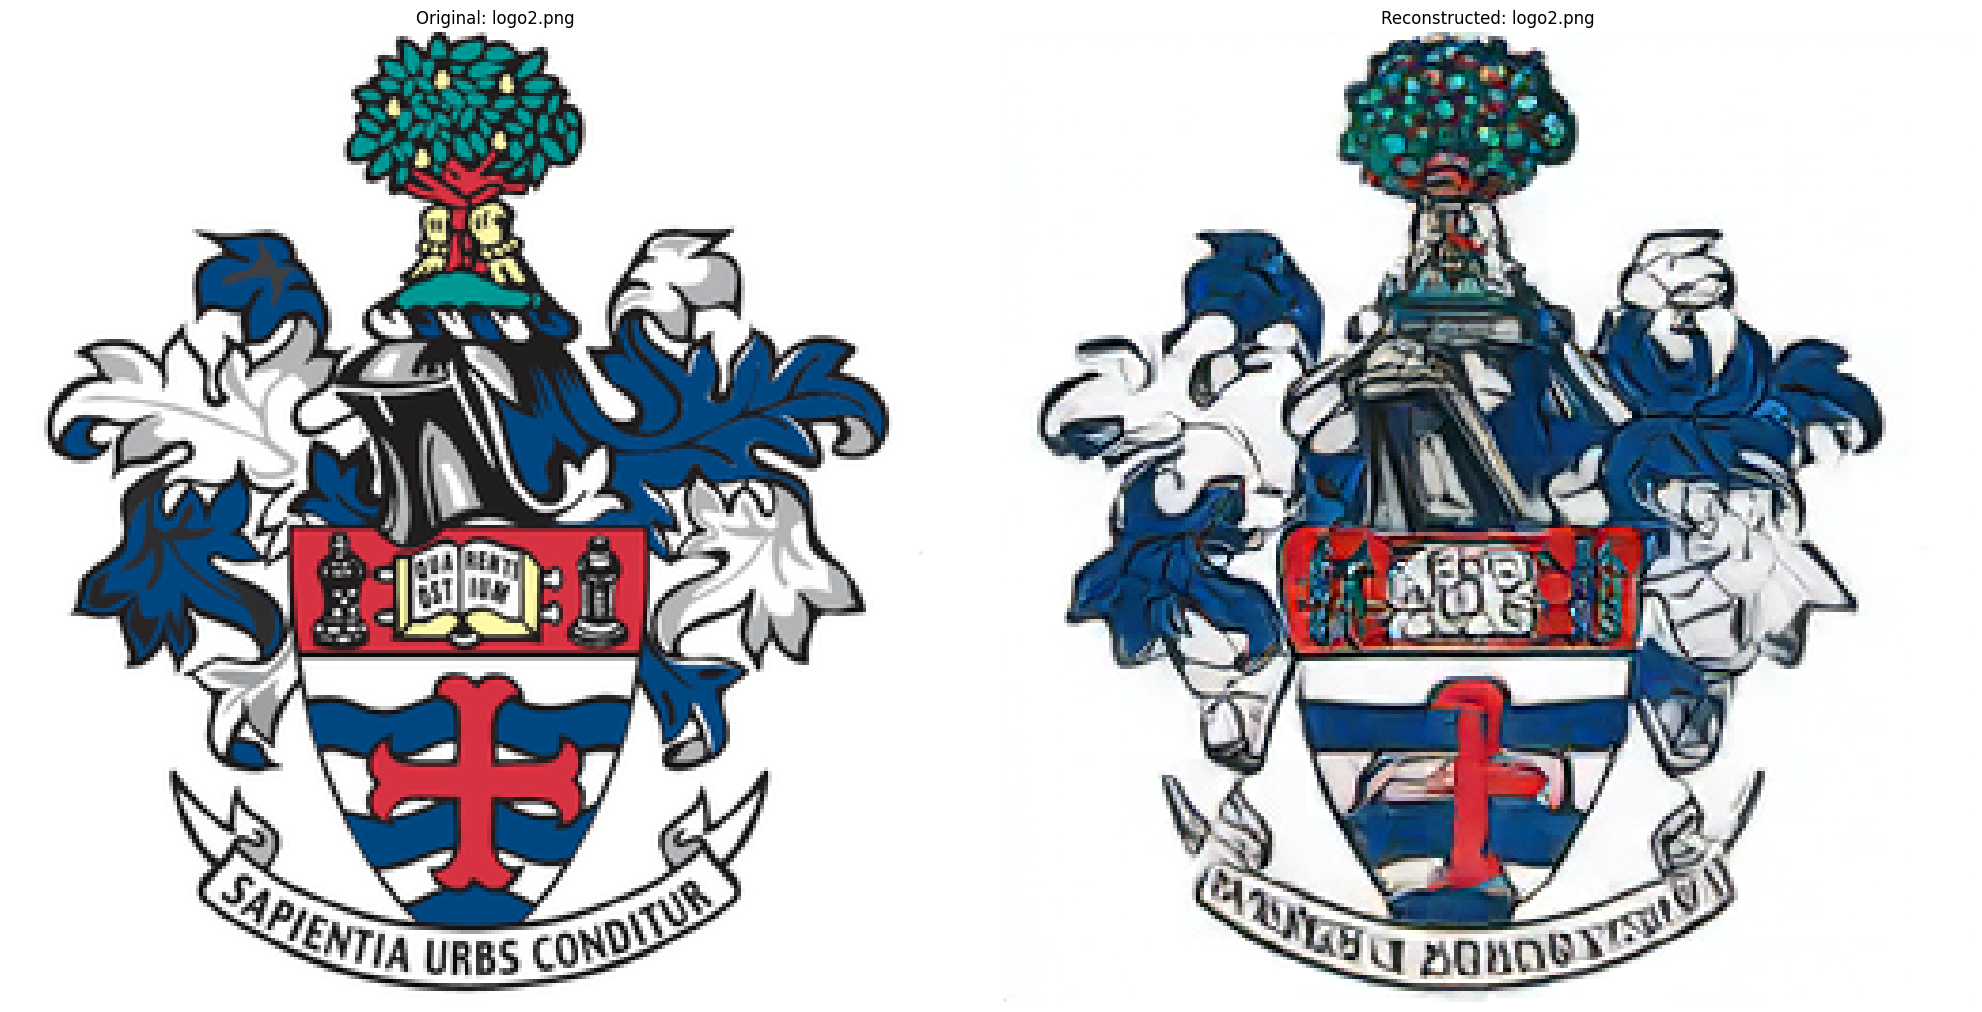


Processing image 5: math_draft1.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
VQ mode - encoded tokens shape: torch.Size([1, 1, 256])
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: math_draft1_256.png


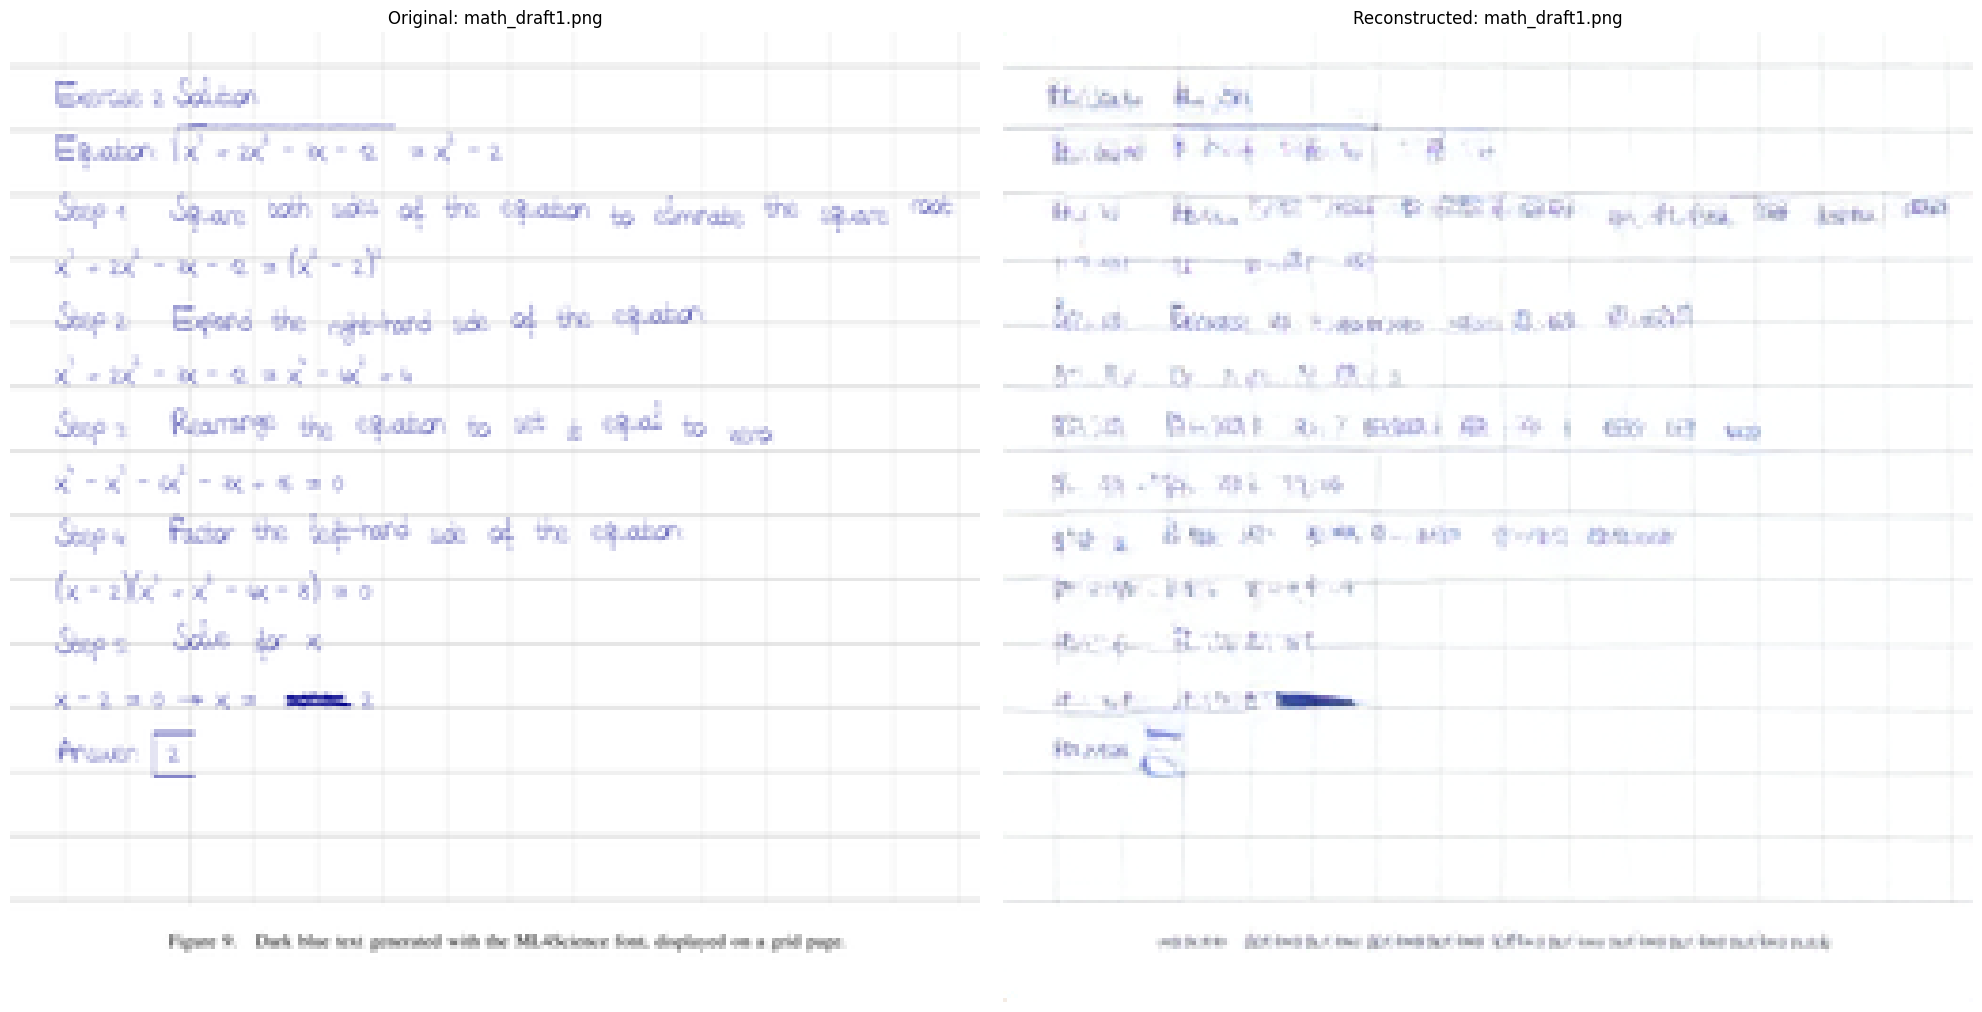


Processing image 6: menu.jpeg
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
VQ mode - encoded tokens shape: torch.Size([1, 1, 256])
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: menu_256.png


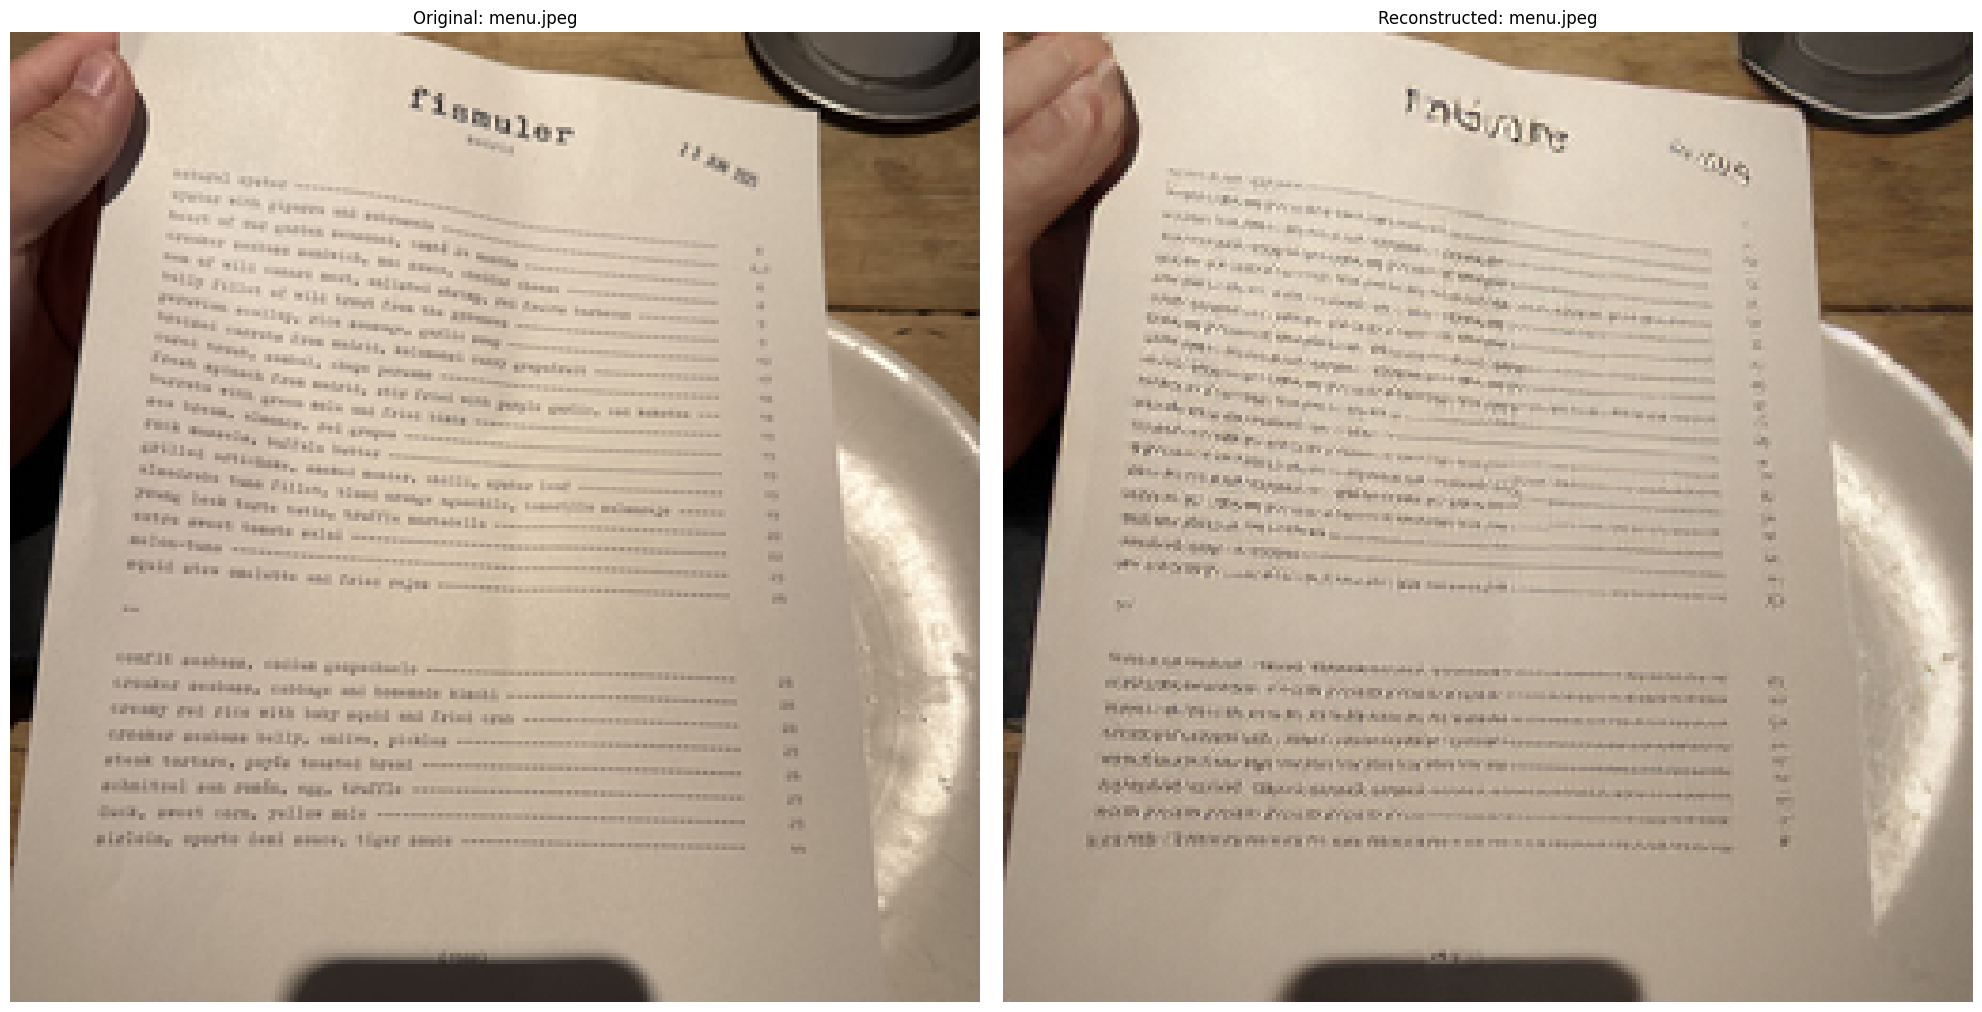


Processing image 7: physics1.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
VQ mode - encoded tokens shape: torch.Size([1, 1, 256])
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: physics1_256.png


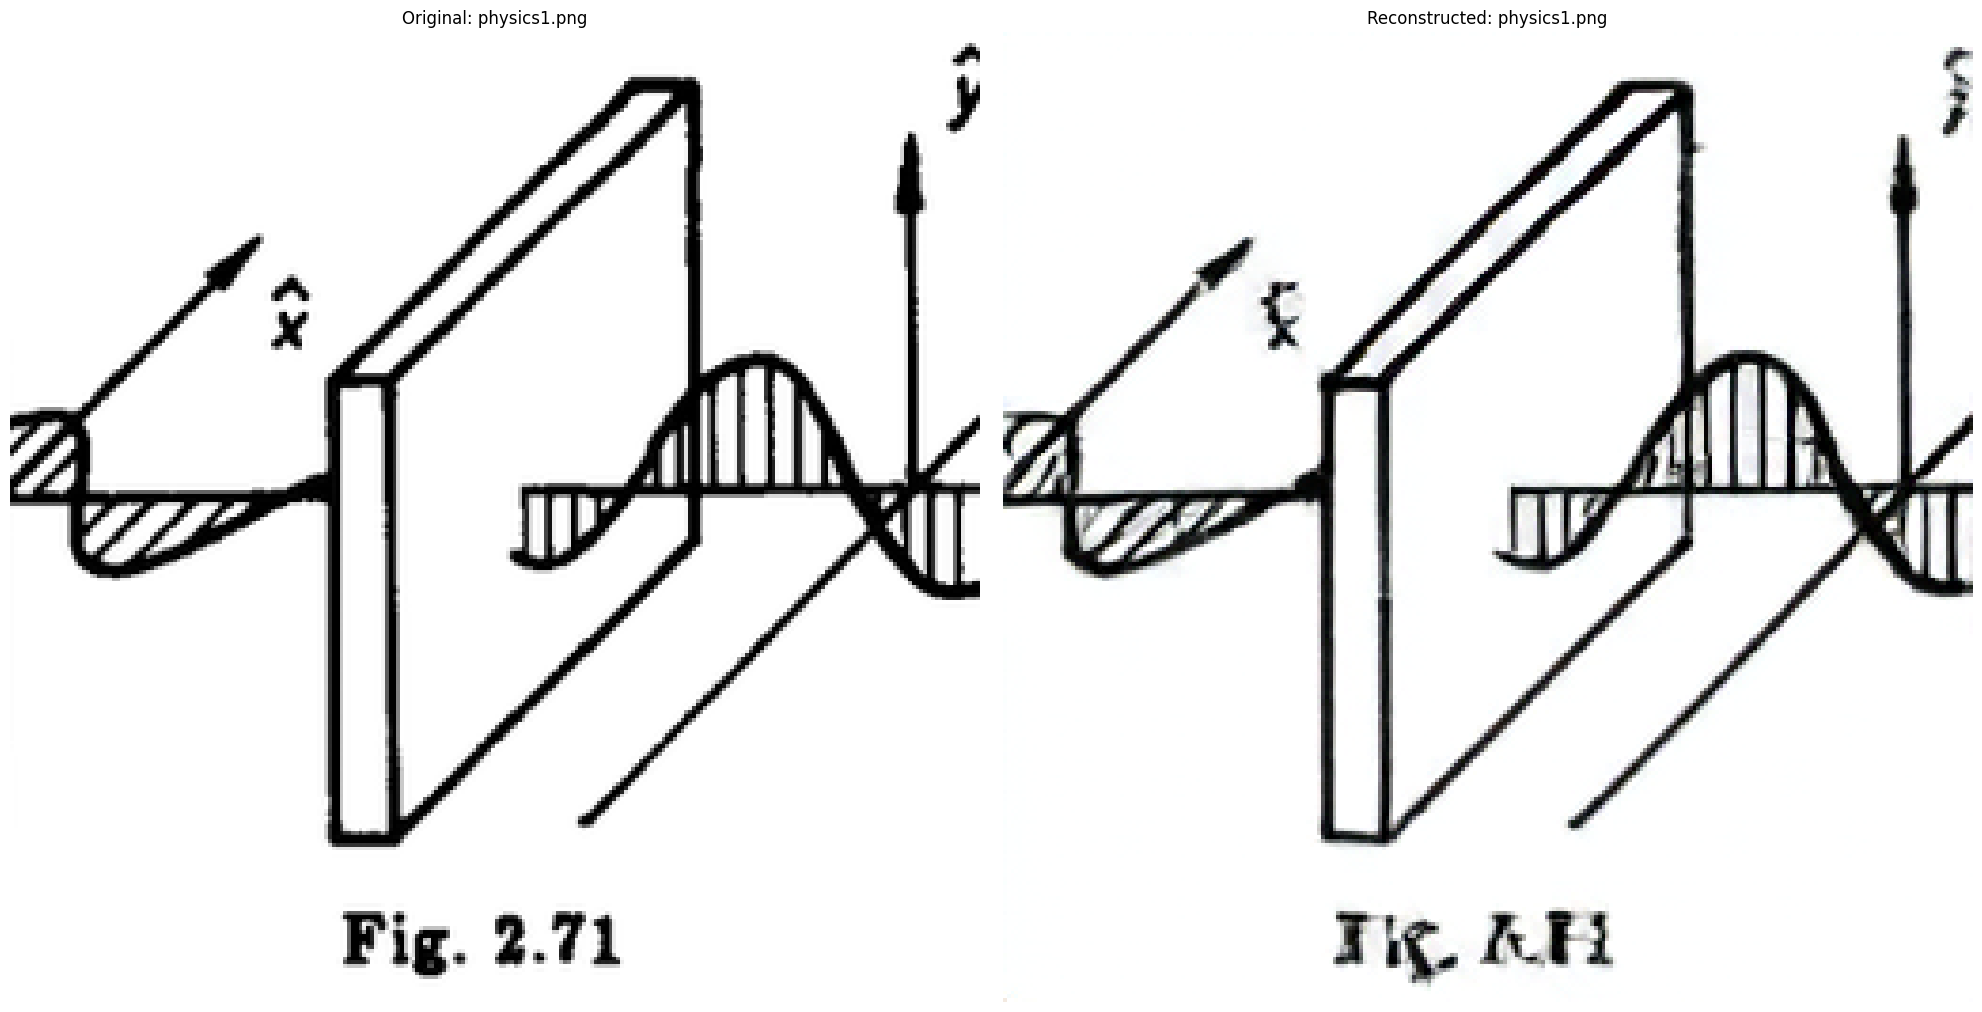


Processing image 8: physics2.png
Input image shape: torch.Size([1, 3, 256, 256])
Image tensor device: cuda:0
VQ mode - encoded tokens shape: torch.Size([1, 1, 256])
Reconstructed tensor shape: torch.Size([1, 3, 256, 256])
Number of tokens: 256
Original image pixels: 65536
Compression ratio: 256.00x
Saved: physics2_256.png


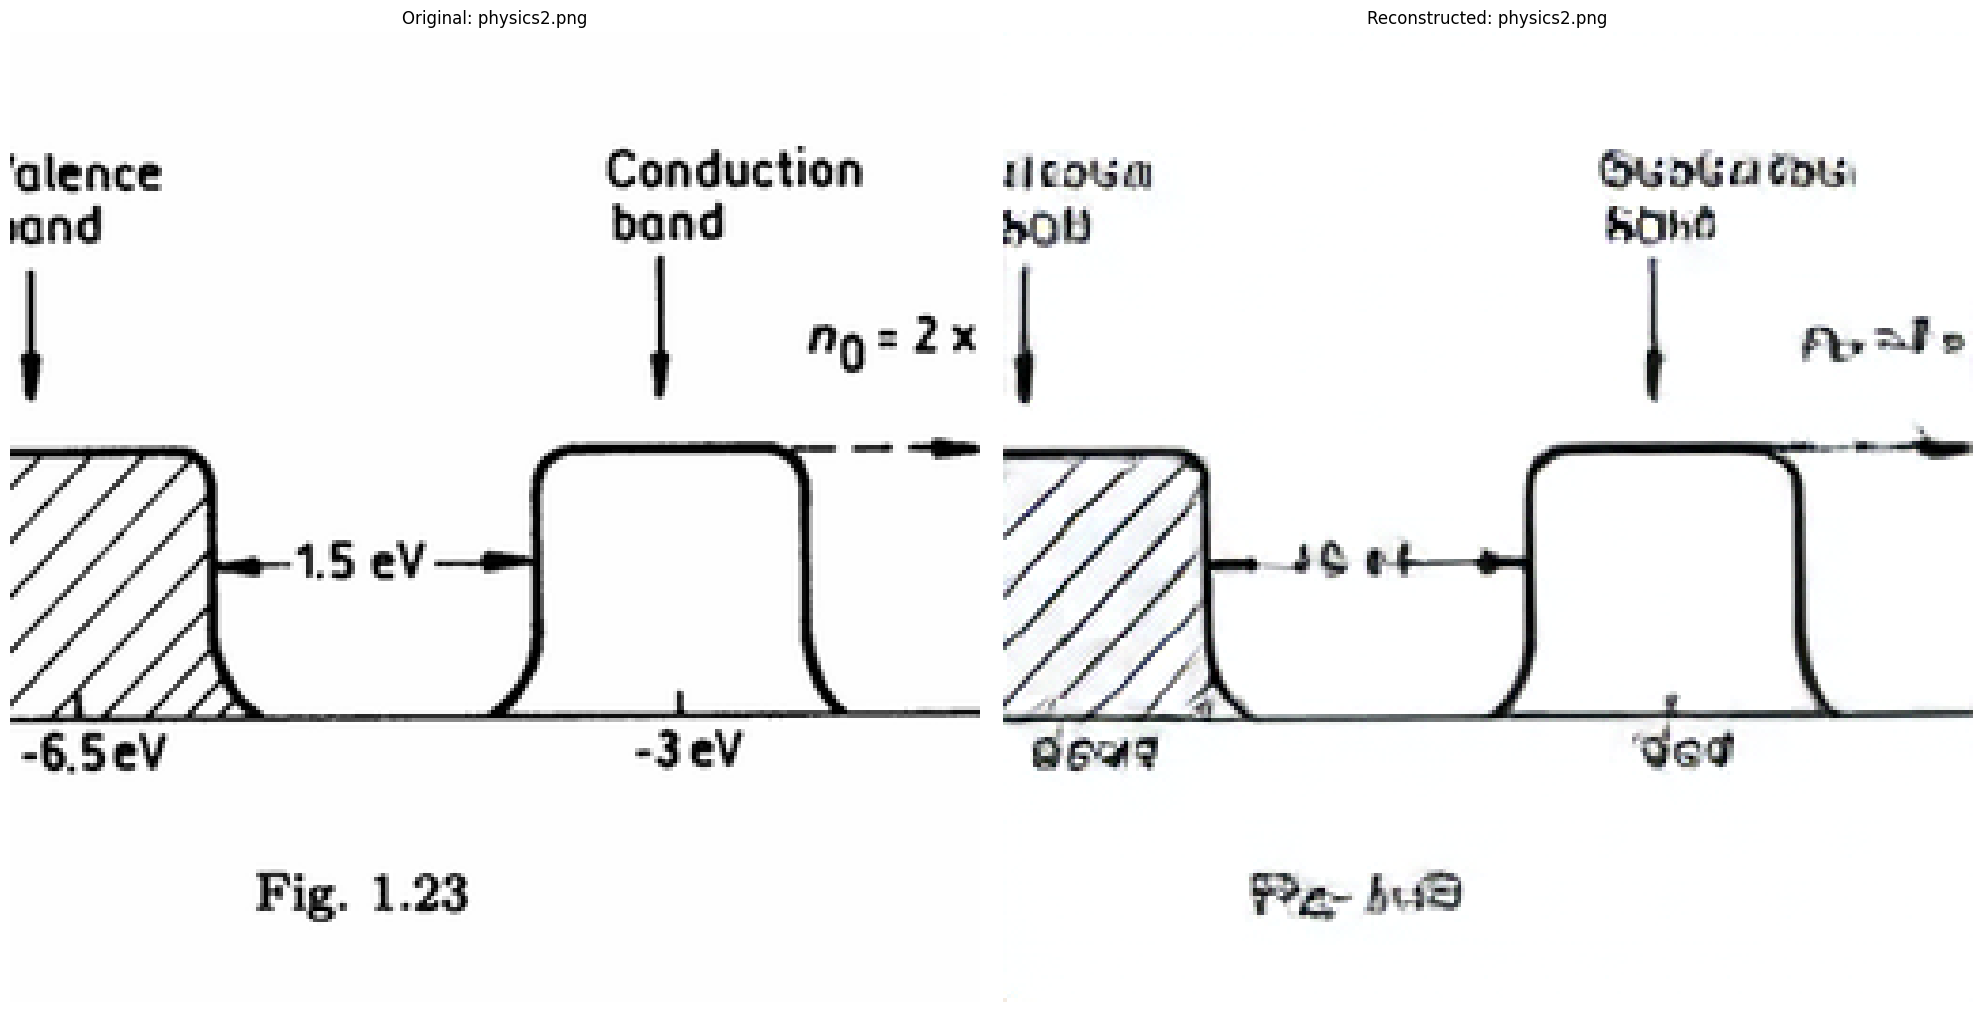

In [54]:
for idx, image_path in enumerate(image_paths):
    name = Path(image_path).name
    print(f"\nProcessing image {idx+1}: {name}")
    
    # Preprocess image
    image_tensor = preprocess_image_for_titok(image_path, size=256, device=device, disable_resize=False)
    
    print(f"Input image shape: {image_tensor.shape}")
    print(f"Image tensor device: {image_tensor.device}")
    
    # TiTok encoding and reconstruction
    with torch.no_grad():
        try:
            # Encode based on quantize mode
            if tokenizer.quantize_mode == "vq":
                encoded_tokens = tokenizer.encode(image_tensor)[1]["min_encoding_indices"]
                print(f"VQ mode - encoded tokens shape: {encoded_tokens.shape}")
                num_tokens = encoded_tokens.numel()
                
            elif tokenizer.quantize_mode == "vae":
                posteriors = tokenizer.encode(image_tensor)[1]
                encoded_tokens = posteriors.sample()
                print(f"VAE mode - encoded tokens shape: {encoded_tokens.shape}")
                num_tokens = encoded_tokens.numel()
            
            # Reconstruct
            recon = tokenizer.decode_tokens(encoded_tokens)
            print(f"Reconstructed tensor shape: {recon.shape}")
            
            print(f"Number of tokens: {num_tokens}")
            print(f"Original image pixels: {image_tensor.shape[-2] * image_tensor.shape[-1]}")
            compression_ratio = (image_tensor.shape[-2] * image_tensor.shape[-1]) / num_tokens
            print(f"Compression ratio: {compression_ratio:.2f}x")
            
        except Exception as e:
            print(f"Error processing {name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Convert back to PIL images
    original_pil = tensor_to_pil_titok(image_tensor)
    recon_pil = tensor_to_pil_titok(recon)
    
    # Save reconstructed image with number of tokens
    name_without_ext = Path(name).stem
    output_filename = f"{name_without_ext}_{num_tokens}.png"
    recon_pil.save(os.path.join(RECONSTRUCTION_PATH, output_filename))
    print(f"Saved: {output_filename}")
    
    # Display comparison
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Original image
    axes[0].imshow(original_pil)
    axes[0].set_title(f"Original: {name}")
    axes[0].axis('off')
    
    # Reconstructed image
    axes[1].imshow(recon_pil)
    axes[1].set_title(f"Reconstructed: {name}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Setup paths
model_name = 'titok_sl256_vq8k'
RECONSTRUCTION_PATH = f'/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/{model_name}'
os.makedirs(RECONSTRUCTION_PATH, exist_ok=True)